# Torch-Rechub 新手教程：双塔召回 (DSSM, Recall)

### 什么是召回，为什么需要召回？

想象一下，你正在为像淘宝、抖音或 YouTube 这样拥有**数千万甚至数亿级**商品或视频的平台构建推荐系统。

当一个用户打开 App 时，系统需要在毫秒级的时间内从这“海量”的物料池中挑选出用户最感兴趣的几十个内容展示出来。这时，我们面临一个巨大的工程挑战：**计算性能与计算精度的矛盾。**

如果我们使用一个非常复杂、极其精准的算法去逐一计算用户对每一个物品的喜爱程度，过程会是这样的：
1. 计算用户对**第 1 个**物品的匹配度，耗时 1ms。
2. 计算用户对**第 2 个**物品的匹配度，耗时 1ms。
3. ...
4. 计算用户对**第 1 亿个**物品的匹配度。

全部算完需要 **10 万秒（约 28 小时）**！用户显然不可能等上一整天才能看到推荐列表。

因此，工业界的推荐系统普遍采用“漏斗式”的分层架构。而**召回 (Recall)** 就是这道漏斗的第一道关卡。

**召回的任务**：从全量亿级物料池中，利用简单的特征和高效的算法，快速筛选出几百到几千个用户“可能感兴趣”的候选物品。  
**召回的目标**：不追求极致的排名精准，但追求极致的**速度**和**覆盖率**（确保把好东西捞出来，别漏掉）。  
### 什么是 DSSM (双塔模型)？

**DSSM (Deep Structured Semantic Models)**，在推荐领域通常被称为**双塔模型 (Two-Tower Model)**。它是目前实现大规模召回阶段最主流、最核心的技术。

DSSM 的核心思想非常直观：**解耦**。它将“用户”和“物品”的信息分别处理，构建了两个相互独立的神经网络，也就是所谓的“双塔”：

1.  **用户塔 (User Tower)**：
    *   **输入**：只包含用户的特征（如用户 ID、年龄、性别、地理位置、历史点击序列等）。
    *   **输出**：一个固定维度的向量（例如 64 维），称为 **User Embedding**。这个向量可以看作是该用户兴趣的高度浓缩表示。

2.  **物品塔 (Item Tower)**：
    *   **输入**：只包含物品的特征（如物品 ID、类别、品牌、价格等）。
    *   **输出**：一个与用户向量维度完全相同的向量，称为 **Item Embedding**。这是物品特征的数值化表达。

**训练的目标：**
在训练过程中，我们希望模型学会：如果用户点击了某个物品，那么该用户的 **User Embedding** 和该物品的 **Item Embedding** 在向量空间中的距离应该**尽可能接近**（相似度高）；反之，如果没点击，距离应该**尽可能远**。
### **DSSM 如何实现闪电般的速度？**

这种“双塔”结构在工程实现上具有巨大的优势，是它能处理亿级数据的关键：

1.  **离线预计算 (Offline)**：
    由于“物品塔”完全不依赖用户信息，我们可以**提前**将全站几亿个物品全部输入物品塔，计算出它们各自的 Item Embedding。然后，将这些向量存入专门的**向量数据库**（如 Faiss 或 Annoy）。这个过程是离线完成的，不占用用户在线等待的时间。

2.  **在线实时检索 (Online)**：
    当用户刷新页面请求推荐时，系统只需要做极少的工作：
    *   **第 1 步**：将当前用户的特征送入“用户塔”，得到该用户的 **User Embedding**（这只是一次简单的神经网络计算，极快）。
    *   **第 2 步**：拿着这个 User Embedding，去向量数据库中进行**近似最近邻搜索 (ANN Search)**。数据库会瞬间从几亿个向量中找出与当前用户最相似的 Top-K 个物品。

**总结：**
DSSM 将原本无法完成的“亿级物料逐一匹配”难题，巧妙地转化为了**“1 次用户塔计算 + 1 次高效向量检索”**。这让推荐系统既能“看得广”（覆盖全量物料），又能“跑得快”（毫秒级响应）。

## 0. **流程概览**：
**场景**：召回 (Matching/Retrieval)  
**模型**：DSSM (Deep Structured Semantic Models)  
**数据**：MovieLens-1M (Sample)  
**流程**：
1. **特征工程**：处理用户历史行为序列，进行标签编码 (Label Encoding)。
2. **模型构建**：定义用户塔 (User Tower) 和物品塔 (Item Tower) 的特征。
3. **模型训练**：使用 `MatchTrainer` 训练 DSSM 模型。
4. **向量化召回**：导出用户和物品的 Embedding 向量，使用 Annoy 进行近邻检索 (ANN)。

In [2]:
import torch
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

from torch_rechub.models.matching import DSSM
from torch_rechub.trainers import MatchTrainer
from torch_rechub.basic.features import SparseFeature, SequenceFeature
from torch_rechub.utils.match import generate_seq_feature_match, gen_model_input, Annoy
from torch_rechub.utils.data import df_to_dict, MatchDataGenerator

torch.manual_seed(2022)
# 如果有显卡可以设置为 'cuda:0'
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


## 1. 数据准备与特征预处理

我们使用 MovieLens-1M 的采样数据集。我们需要做两件事：
1. **Label Encoding**：将 ID 类特征（如 UserID, City, Genre）映射为从 0 开始的整数。
2. **构建侧特征 (Profile)**：将数据拆分为“用户画像”和“物品画像”，方便构建双塔。

In [3]:
# 读取数据 (这里使用 repo 中自带的 sample 数据，实际使用时可替换为全量数据)
file_path = '../examples/matching/data/ml-1m/ml-1m_sample.csv'
save_dir = '../examples/matching/data/ml-1m/saved/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

data = pd.read_csv(file_path)

# 简单的特征处理：genres字段是"Drama|Comedy"这种形式，为了简单起见，我们只取第一个类别
data["cate_id"] = data["genres"].apply(lambda x: x.split("|")[0])

# 定义特征列名
user_col, item_col = "user_id", "movie_id"
sparse_features = ['user_id', 'movie_id', 'gender', 'age', 'occupation', 'zip', "cate_id"]

# 1. Label Encoding (将字符串/原始ID转换为模型可读的整数索引)
feature_max_idx = {}
user_map, item_map = {}, {} # 用于最后把结果还原回原始ID

for feature in sparse_features:
    lbe = LabelEncoder()
    data[feature] = lbe.fit_transform(data[feature]) + 1 # +1 是为了给 padding (0) 留出位置
    feature_max_idx[feature] = data[feature].max() + 1
    
    if feature == user_col:
        user_map = {encode_id + 1: raw_id for encode_id, raw_id in enumerate(lbe.classes_)}
    if feature == item_col:
        item_map = {encode_id + 1: raw_id for encode_id, raw_id in enumerate(lbe.classes_)}

print("Feature max indices:", feature_max_idx)
print("Data Preview:")
print(data.head())

Feature max indices: {'user_id': np.int64(3), 'movie_id': np.int64(94), 'gender': np.int64(3), 'age': np.int64(3), 'occupation': np.int64(3), 'zip': np.int64(3), 'cate_id': np.int64(11)}
Data Preview:
   user_id  movie_id  rating  timestamp  \
0        1        32       5  978300760   
1        1        17       3  978302109   
2        1        22       3  978301968   
3        1        91       4  978300275   
4        1        66       5  978824291   

                                    title                        genres  \
0  One Flew Over the Cuckoo's Nest (1975)                         Drama   
1        James and the Giant Peach (1996)  Animation|Children's|Musical   
2                     My Fair Lady (1964)               Musical|Romance   
3                  Erin Brockovich (2000)                         Drama   
4                    Bug's Life, A (1998)   Animation|Children's|Comedy   

   gender  age  occupation  zip  cate_id  
0       1    1           1    1        7  
1  

## 2. 生成序列特征与负采样

召回模型通常需要用户的**历史行为序列**（例如：过去看过哪些电影）来表达用户兴趣。
同时，我们需要生成**负样本**（用户没看过的电影）来训练模型区分“喜欢”和“不喜欢”。

- `mode=0`：Point-wise 模式，将数据构造成 (User, Item, Label) 的形式，Label=1 为正样本，Label=0 为负样本。
- `neg_ratio=3`：每个正样本对应生成 3 个负样本。

In [4]:
# 生成序列特征 (History) 和 训练集/测试集划分
df_train, df_test = generate_seq_feature_match(
    data,
    user_col, 
    item_col,
    time_col="timestamp",
    item_attribute_cols=[],
    sample_method=1, # 随机负采样
    mode=0,          # Point-wise 训练模式
    neg_ratio=3,     # 正负样本比例 1:3
    min_item=0       # 过滤掉交互过少的冷启动用户
)

# 准备用户侧和物品侧的静态特征表
user_cols = ["user_id", "gender", "age", "occupation", "zip"]
item_cols = ["movie_id", "cate_id"]
user_profile = data[user_cols].drop_duplicates('user_id')
item_profile = data[item_cols].drop_duplicates('movie_id')

# 将 DataFrame 转换为模型输入的 Dict 格式
x_train = gen_model_input(df_train, user_profile, user_col, item_profile, item_col, seq_max_len=50)
y_train = x_train["label"]

x_test = gen_model_input(df_test, user_profile, user_col, item_profile, item_col, seq_max_len=50)
y_test = x_test["label"]

print(f"Train samples: {len(df_train)}, Test samples: {len(df_test)}")

preprocess data


generate sequence features: 100%|██████████| 2/2 [00:00<00:00, 1030.67it/s]

n_train: 384, n_test: 2
0 cold start user dropped 
Train samples: 384, Test samples: 2


## 3. 定义 DSSM 模型

DSSM 是经典的双塔结构：
1. **User Tower**: 输入用户 ID、人口统计学特征、历史观看序列。输出 User Embedding。
2. **Item Tower**: 输入电影 ID、电影类别。输出 Item Embedding。
3. **Similarity**: 计算两个 Embedding 的余弦相似度或点积。

In [5]:
# 3.1 定义 User 塔的特征
user_features = [
    SparseFeature(name, vocab_size=feature_max_idx[name], embed_dim=16) 
    for name in user_cols
]
# 添加用户的历史行为序列特征
user_features += [
    SequenceFeature("hist_movie_id",
                    vocab_size=feature_max_idx["movie_id"],
                    embed_dim=16,
                    pooling="mean",  # 序列特征取平均
                    shared_with="movie_id") # 和物品侧的 movie_id 共享 Embedding 矩阵
]

# 3.2 定义 Item 塔的特征
item_features = [
    SparseFeature(name, vocab_size=feature_max_idx[name], embed_dim=16) 
    for name in item_cols
]

# 3.3 初始化 DSSM 模型
model = DSSM(
    user_features,
    item_features,
    temperature=0.02,
    user_params={
        "dims": [256, 128, 64], # 用户塔 MLP 的层结构
        "activation": 'prelu', 
    },
    item_params={
        "dims": [256, 128, 64], # 物品塔 MLP 的层结构，最后一层维度必须与 User 塔一致 (64)
        "activation": 'prelu',
    }
)

DSSM模型可视化：
（可视化教程详见：https://datawhalechina.github.io/torch-rechub/zh/tools/visualization.html ；后续不再赘述）

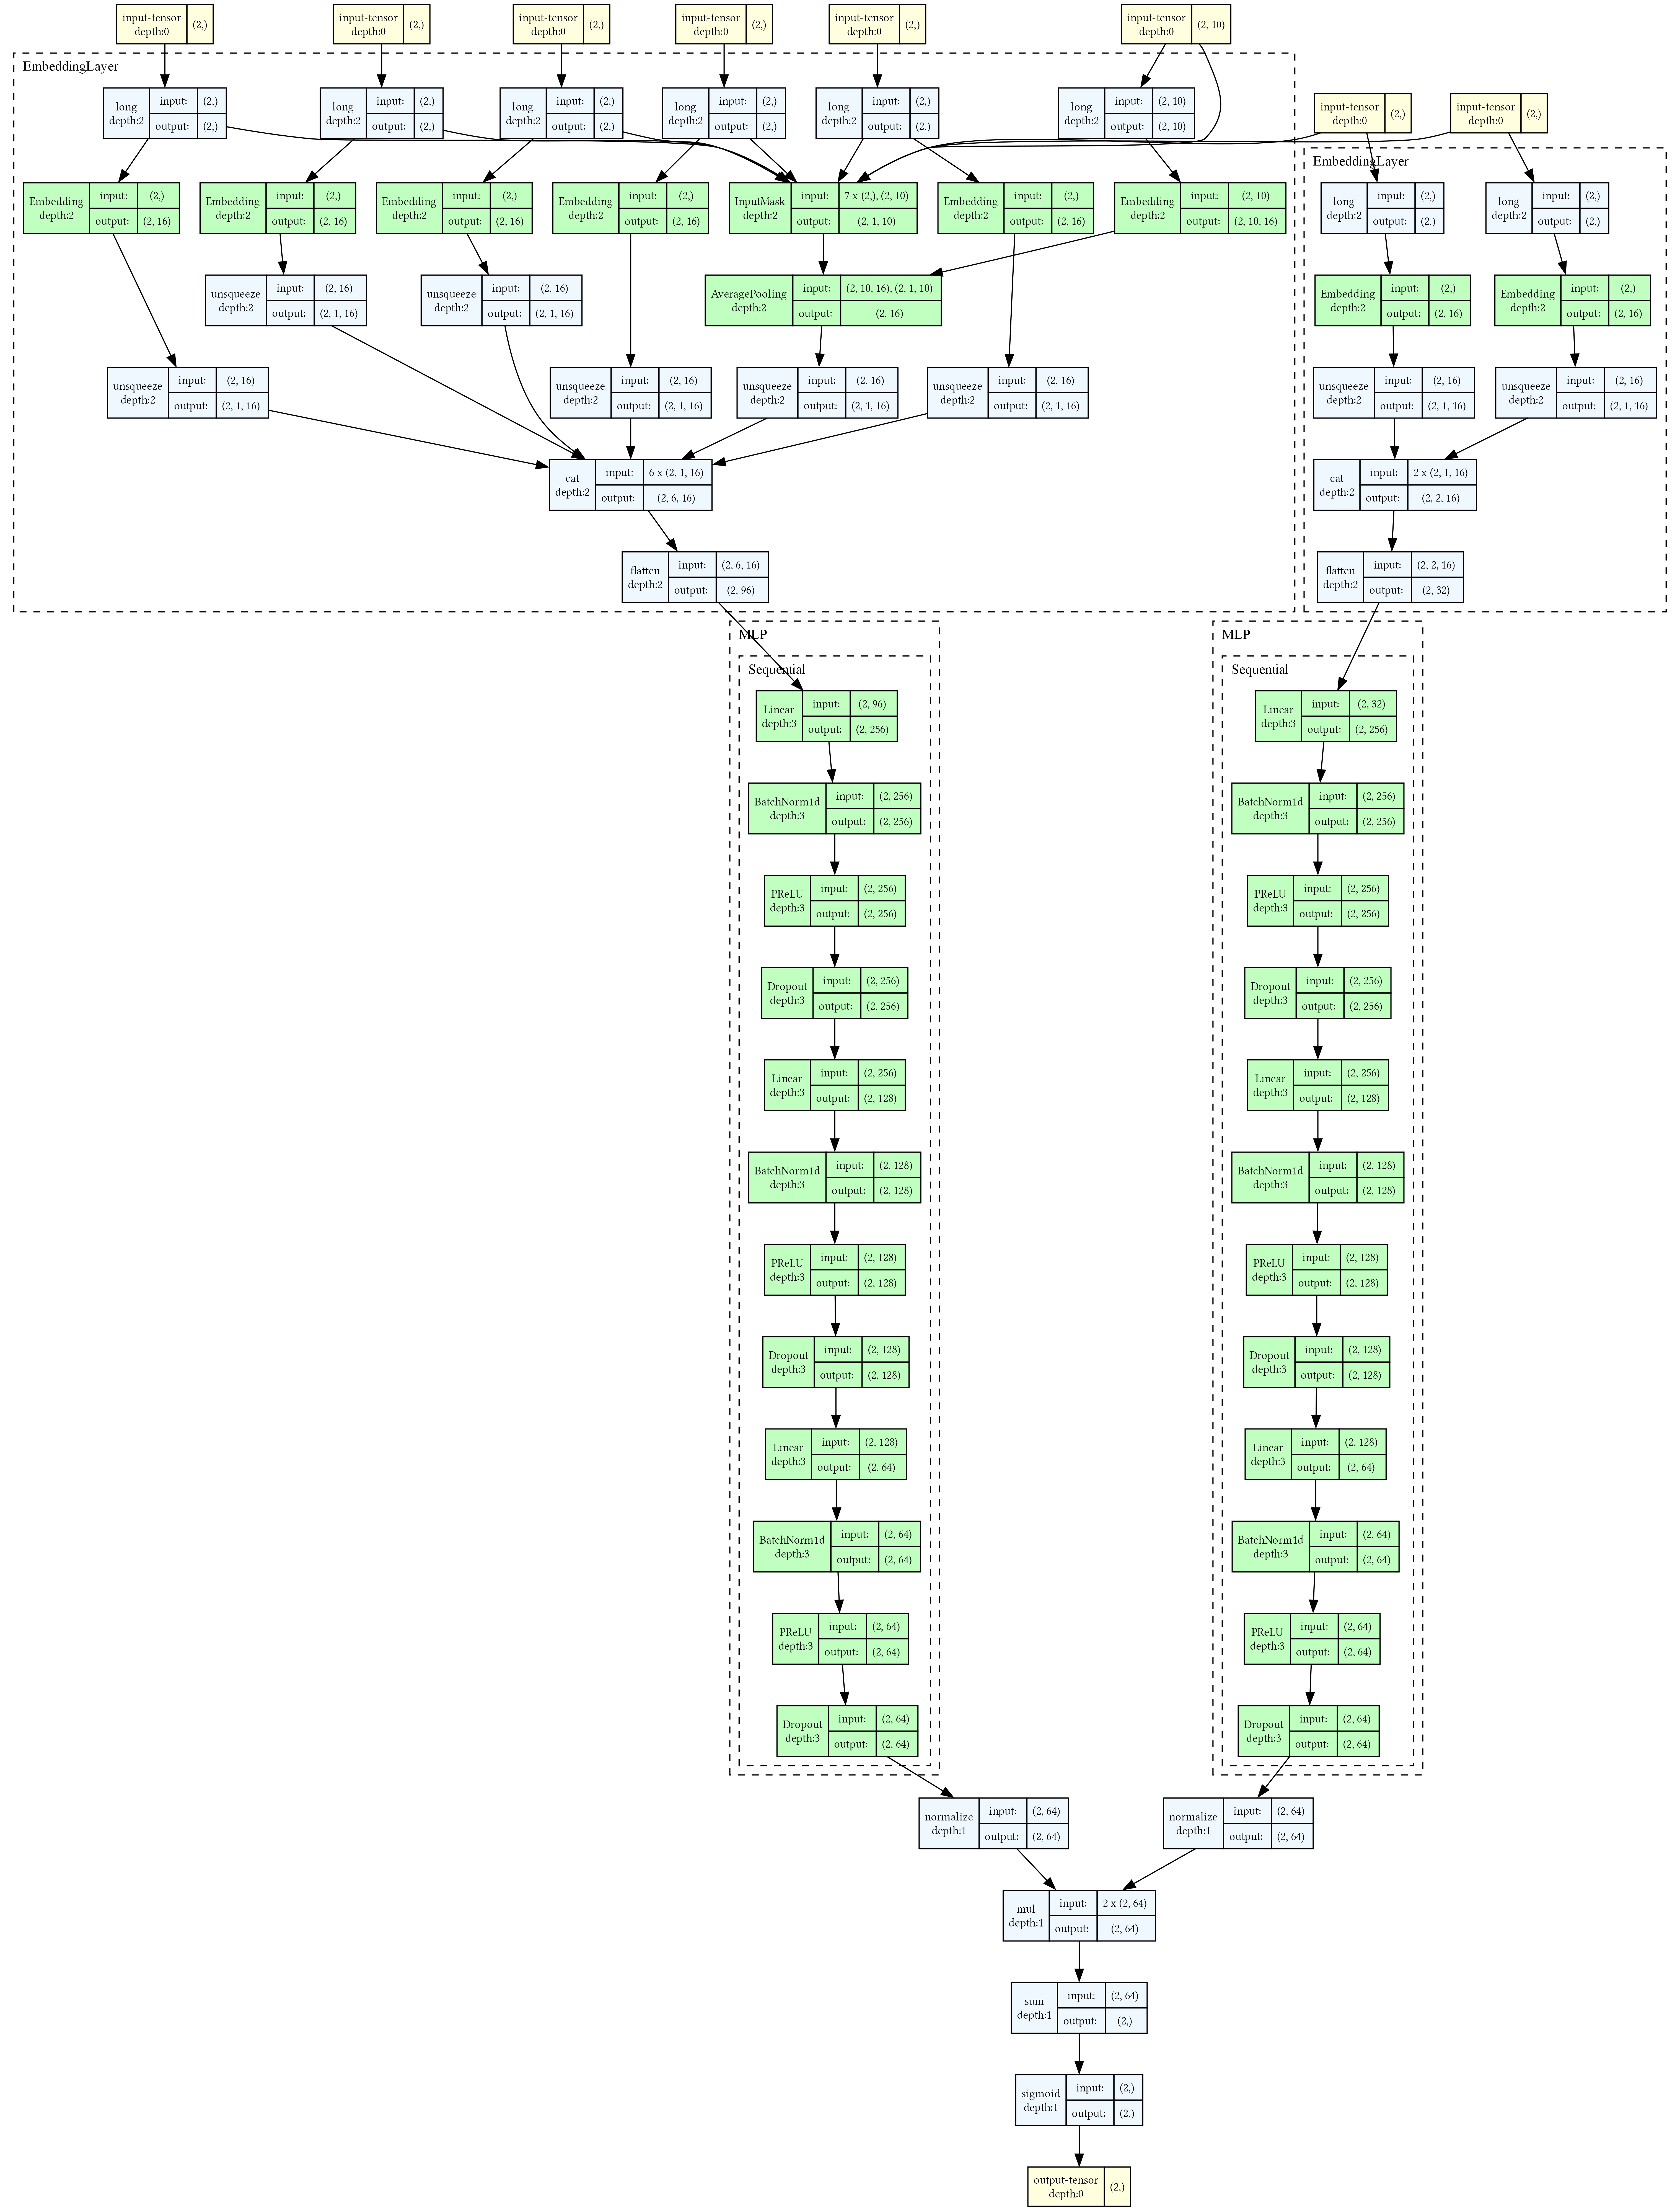

In [6]:
from torch_rechub.utils.visualization import visualize_model
graph = visualize_model(model, depth=4)

**DSSM模型的结构：**
```text
DSSM(
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (user_id): Embedding(3, 16)
      (gender): Embedding(3, 16)
      (age): Embedding(3, 16)
      (occupation): Embedding(3, 16)
      (zip): Embedding(3, 16)
      (movie_id): Embedding(94, 16)
      (cate_id): Embedding(11, 16)
    )
  )
  (user_mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=96, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Dropout(p=0, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): PReLU(num_parameters=1)
      (7): Dropout(p=0, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): PReLU(num_parameters=1)
      (11): Dropout(p=0, inplace=False)
    )
  )
  (item_mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Dropout(p=0, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): PReLU(num_parameters=1)
      (7): Dropout(p=0, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): PReLU(num_parameters=1)
      (11): Dropout(p=0, inplace=False)
    )
  )
)
```
DSSM一共分为四部分：
1. Embedding 层（特征嵌入层）:
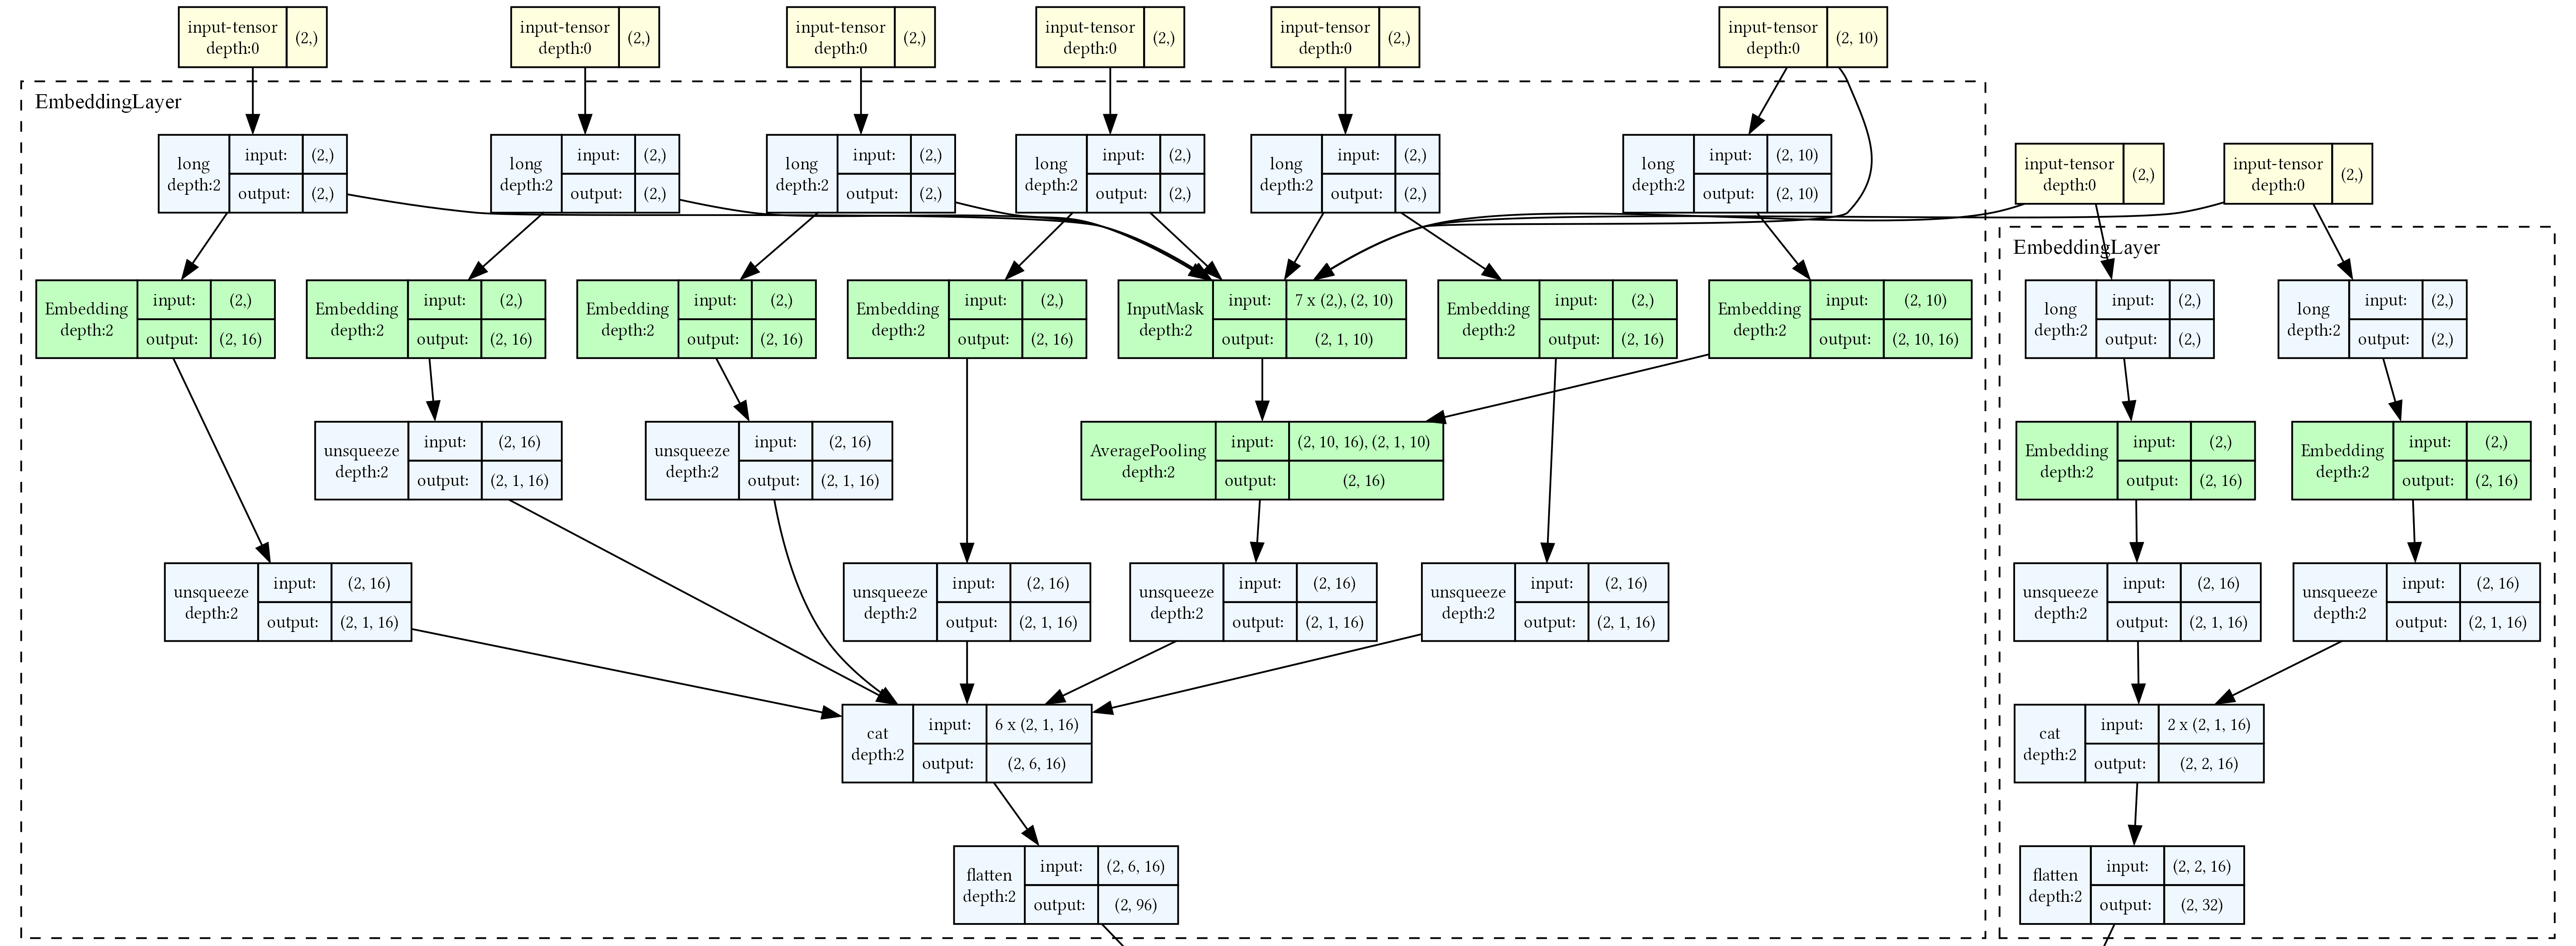
```text
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (user_id): Embedding(3, 16)
      (gender): Embedding(3, 16)
      (age): Embedding(3, 16)
      (occupation): Embedding(3, 16)
      (zip): Embedding(3, 16)
      (movie_id): Embedding(94, 16)
      (cate_id): Embedding(11, 16)
    )
  )
```
包含 7 个离散特征的 embedding：  
用户侧特征：user_id,gender,age,occupation,zip。  
物品侧特征：movie_id,cate_id。  
每个特征被映射为 16 维向量。  
**作用**：  
将离散类别特征转换为稠密向量表示  
学习特征的隐含语义表示  
降低高维 one-hot 特征的维度  
**输出维度**：  
用户侧：6 × 16 = 96 维  
物品侧：2 × 16 = 32 维  
分别作为 user_mlp 和 item_mlp 的输入。  

2. User Tower（用户塔）：  
![user tower.png](<attachment:user tower.png>)
```text
  (user_mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=96, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Dropout(p=0, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): PReLU(num_parameters=1)
      (7): Dropout(p=0, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): PReLU(num_parameters=1)
      (11): Dropout(p=0, inplace=False)
    )
  )
```
**网络结构**：  
96 → 256 → 128 → 64(每层特征维度大小变化)  
**每一层包含**：  
Linear（全连接层）  
BatchNorm1d（批归一化）  
PReLU（激活函数）  
Dropout（正则化）  
**作用**：  
对用户特征进行非线性变换  
学习高阶特征交互  
将用户特征映射到统一语义空间  
输出 64 维用户向量（user embedding）

3. Item Tower（物品塔）：  
![item tower.png](<attachment:item tower.png>)
```text
  (item_mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=32, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Dropout(p=0, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): PReLU(num_parameters=1)
      (7): Dropout(p=0, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): PReLU(num_parameters=1)
      (11): Dropout(p=0, inplace=False)
    )
  )
```
**网络结构**:  
32 → 256 → 128 → 64(每层特征维度大小变化)  
结构与 user_mlp 对称。  
**作用**：  
对物品特征进行非线性变换  
学习物品内部特征关系  
将物品特征映射到与用户相同的语义空间  
输出 64 维物品向量（item embedding）

4. 相似度计算：  
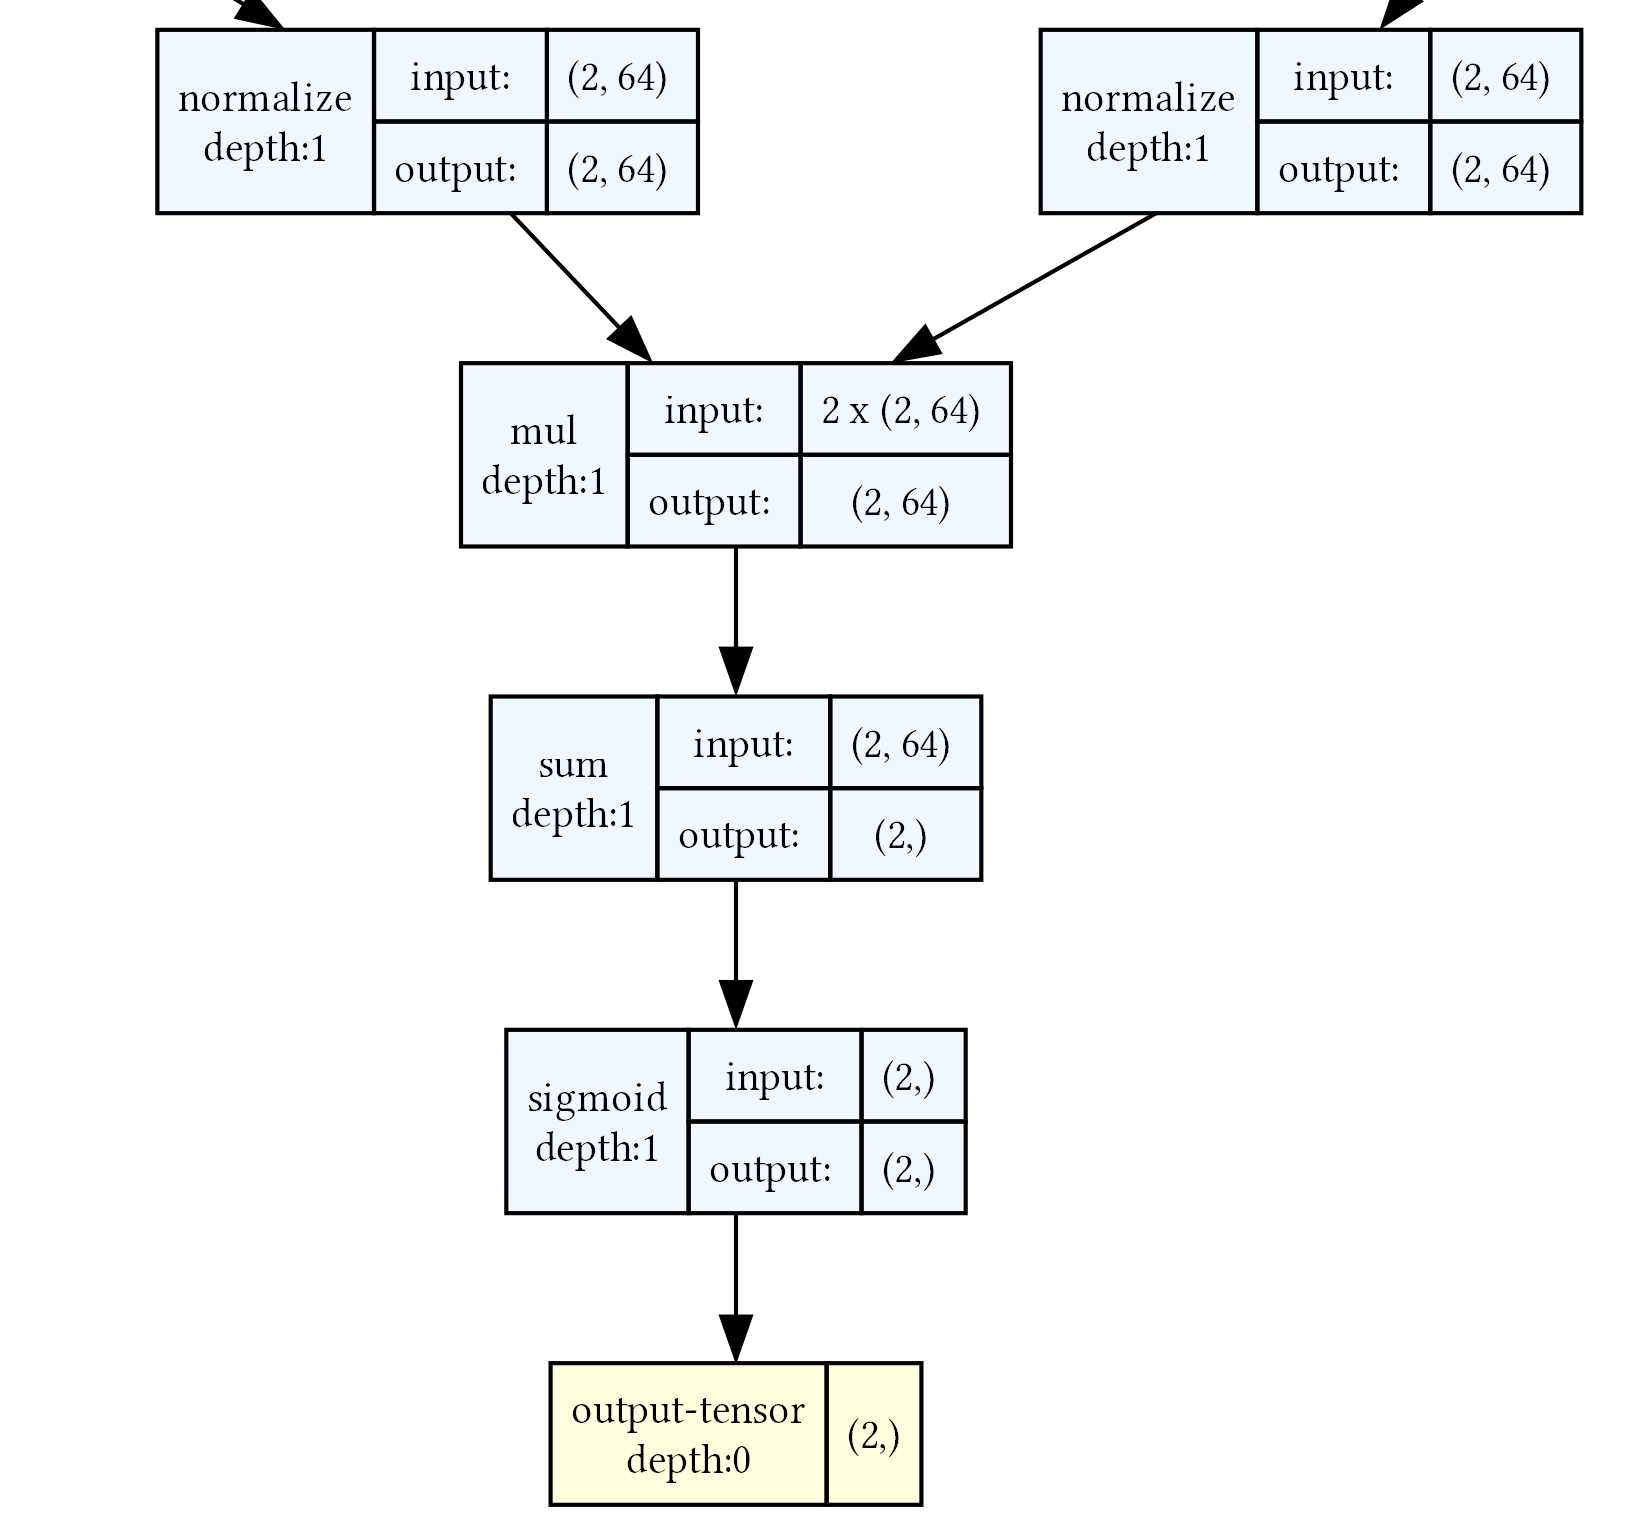

print(model) 只会打印模型的子模块结构，相似度计算通常不会被定义成一个子模块,而是 forward 过程中的张量运算，所以未被打印出来；但是也很重要。  
**DSSM 的核心计算为**：  
score = user_embedding · item_embedding( · ：点积（Dot Product）)  
**功能**：  
计算用户向量与物品向量之间的匹配程度  
生成推荐分数  
作为训练阶段的优化目标依据  
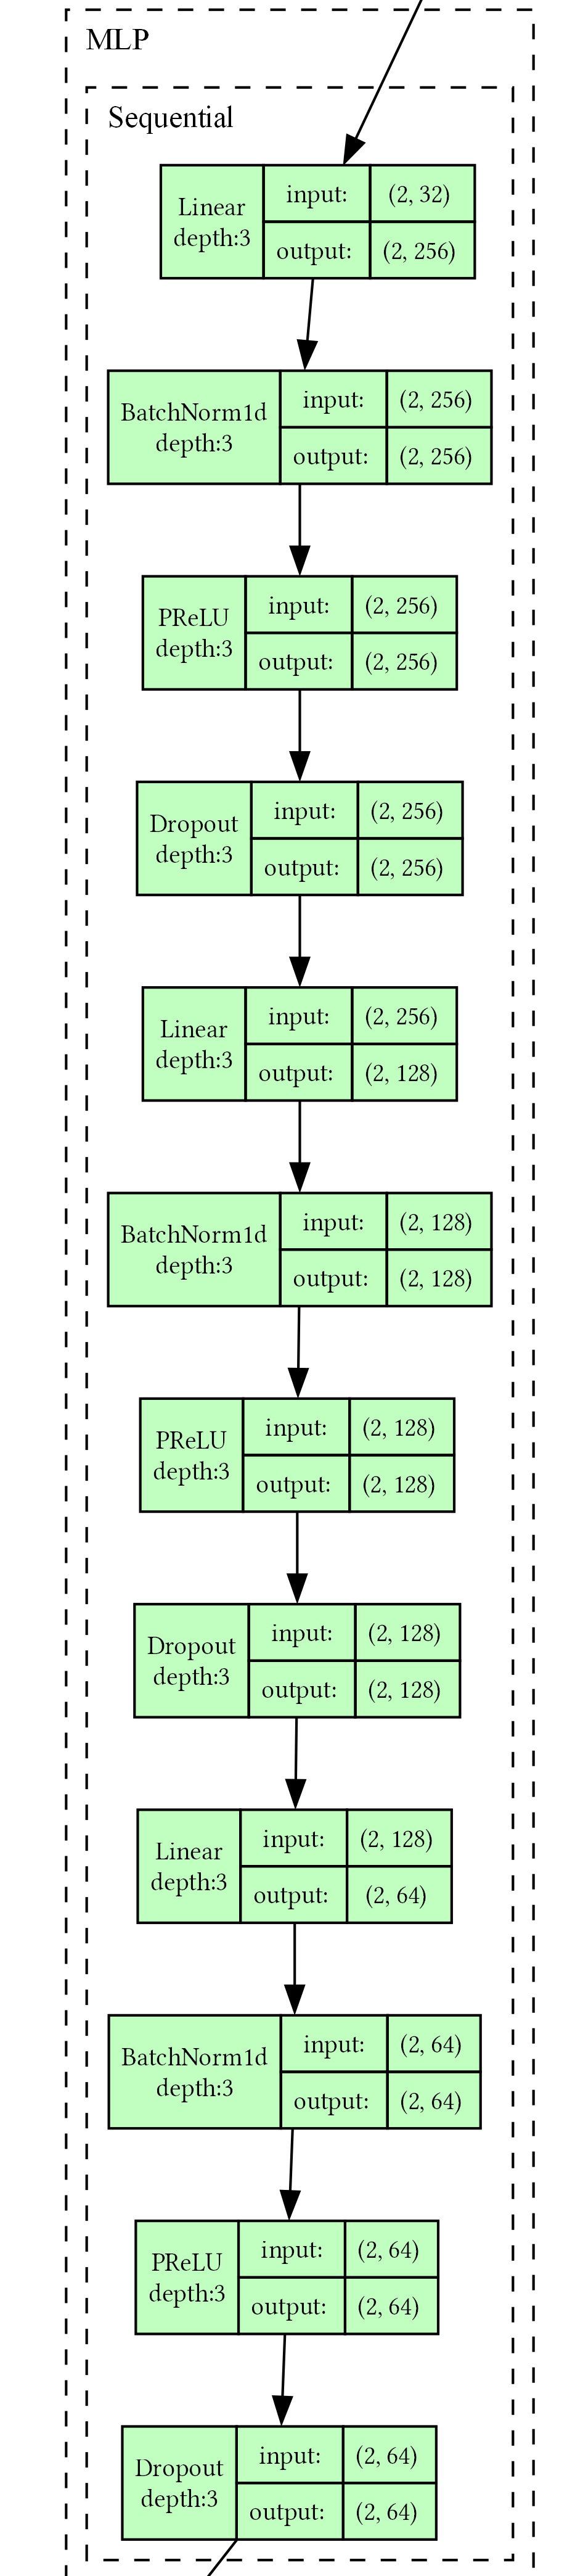
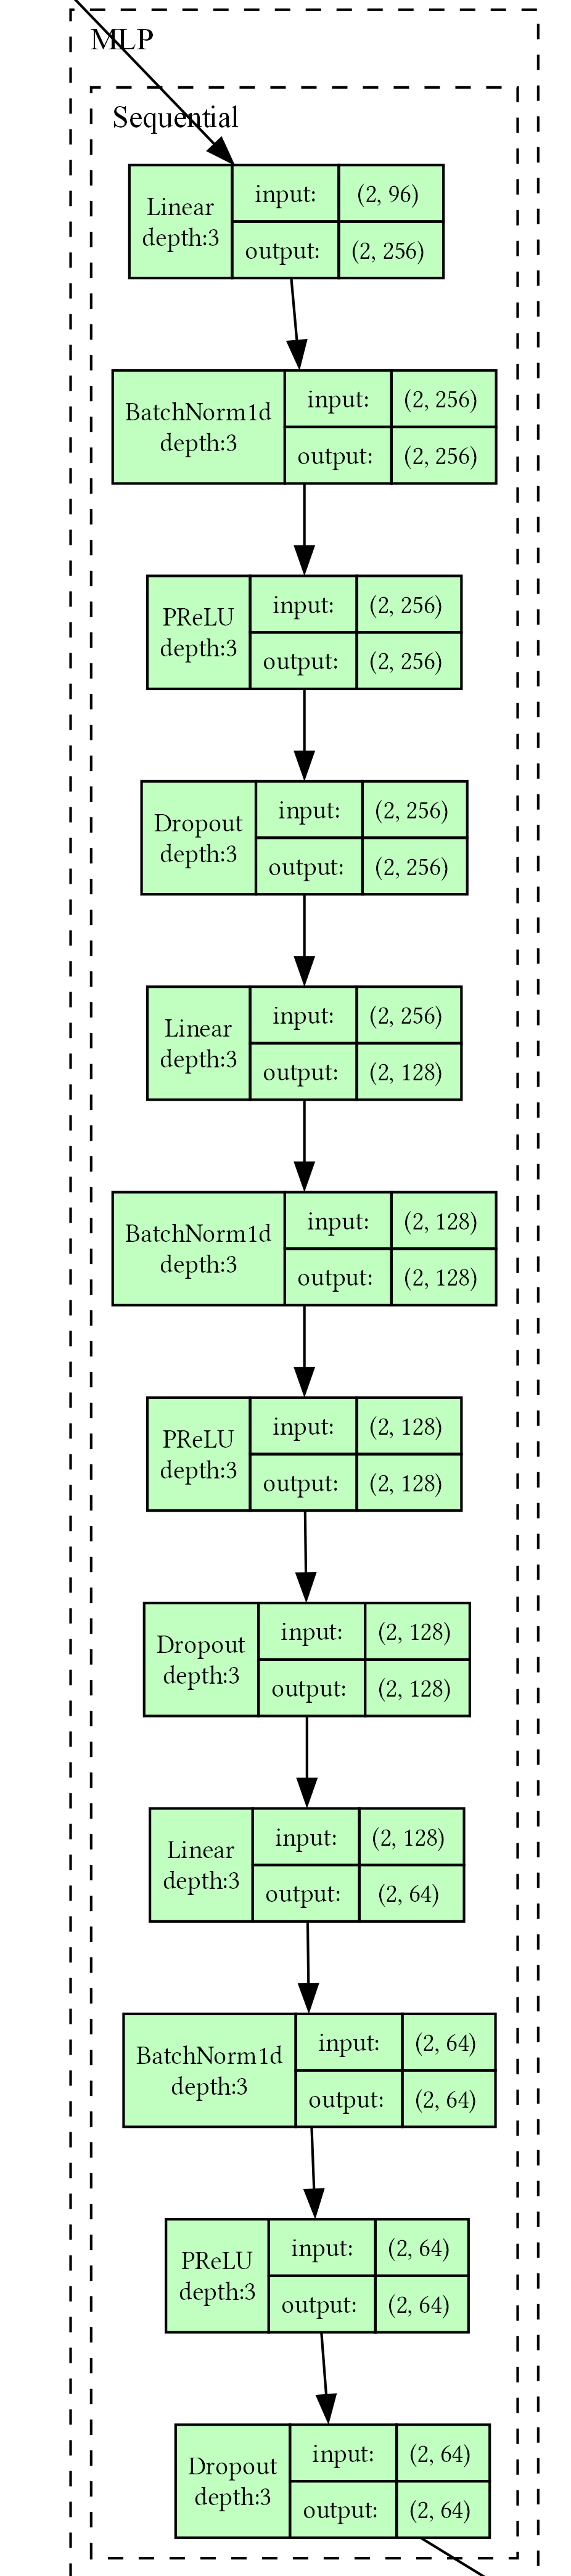

In [7]:
print(model)

DSSM(
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (user_id): Embedding(3, 16)
      (gender): Embedding(3, 16)
      (age): Embedding(3, 16)
      (occupation): Embedding(3, 16)
      (zip): Embedding(3, 16)
      (movie_id): Embedding(94, 16)
      (cate_id): Embedding(11, 16)
    )
    (input_mask): InputMask()
  )
  (user_mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=96, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): PReLU(num_parameters=1)
      (3): Dropout(p=0, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): PReLU(num_parameters=1)
      (7): Dropout(p=0, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

## 4. 训练模型

使用 `MatchTrainer` 进行训练。在训练过程中，模型会学习如何将“匹配”的用户和物品映射到向量空间中相近的位置。

In [8]:
# 生成 DataLoader
dg = MatchDataGenerator(x=x_train, y=y_train)
# all_item 用于在预测阶段生成所有物品的向量
all_item = df_to_dict(item_profile)
train_dl, test_dl, item_dl = dg.generate_dataloader(x_test, all_item, batch_size=256)

# 定义训练器
trainer = MatchTrainer(
    model,
    mode=0, # 需与数据生成时的 mode 保持一致
    optimizer_params={"lr": 1e-4, "weight_decay": 1e-6},
    n_epoch=1,
    device=device,
    model_path=save_dir
)

# 开始训练
trainer.fit(train_dl)

epoch: 0


train: 100%|██████████| 2/2 [00:16<00:00,  8.03s/it]


## 5. 向量化召回与评估

训练完成后，我们不再通过输入 (User, Item) 预测 0/1，而是：
1. **Inference**: 将所有物品输入物品塔，得到 Item Embeddings 库。
2. **User Embedding**: 将目标用户输入用户塔，得到 User Embedding。
3. **ANN Search**: 使用 Annoy 库在 Item Embeddings 库中搜索与 User Embedding 最相似的 Top-K 个物品。

In [9]:
print("提取所有物品的向量...")
item_embedding = trainer.inference_embedding(model=model, mode="item", data_loader=item_dl, model_path=save_dir)

print("提取测试集用户的向量...")
user_embedding = trainer.inference_embedding(model=model, mode="user", data_loader=test_dl, model_path=save_dir)

# 构建 Annoy 索引 (用于快速最近邻搜索)
annoy = Annoy(n_trees=10)
annoy.fit(item_embedding)

# 进行 Top-10 召回展示
print("\n--- Top 10 推荐结果示例 ---")
topk = 10
for i, user_emb in enumerate(user_embedding[:3]): # 只看前3个用户
    # 1. 拿到用户原始ID
    user_encoded_id = x_test['user_id'][i]
    raw_user_id = user_map[user_encoded_id]
    
    # 2. 拿到用户真实看过的物品 (Ground Truth)
    # 注意：这里简单展示，实际上 x_test 每一行只对应一个 label (pos or neg)。
    # 在完整评估中，应该把该用户所有正样本聚合起来对比。
    target_encoded_item = x_test['movie_id'][i]
    raw_target_item = item_map[target_encoded_item]
    
    # 3. 使用 Annoy 检索 TopK
    items_idx, items_scores = annoy.query(v=user_emb, n=topk)
    
    # 4. 将索引转换回原始 Item ID
    # item_dl 生成的 embedding 顺序与 item_profile 也就是 all_item 的顺序一致
    rec_item_raw_ids = [item_map[all_item[item_col][idx]] for idx in items_idx]
    
    print(f"用户 ID: {raw_user_id}")
    print(f"目标测试物品 ID: {raw_target_item}")
    print(f"模型召回 Top{topk} 物品 IDs: {rec_item_raw_ids}")
    print("-" * 30)

提取所有物品的向量...


item inference: 100%|██████████| 1/1 [00:03<00:00,  3.33s/it]


提取测试集用户的向量...


user inference: 100%|██████████| 1/1 [00:03<00:00,  3.35s/it]


--- Top 10 推荐结果示例 ---
用户 ID: 1
目标测试物品 ID: 48
模型召回 Top10 物品 IDs: [np.int64(1097), np.int64(1270), np.int64(3186), np.int64(1035), np.int64(3035), np.int64(1246), np.int64(919), np.int64(1253), np.int64(1961), np.int64(3105)]
------------------------------
用户 ID: 2
目标测试物品 ID: 434
模型召回 Top10 物品 IDs: [np.int64(1097), np.int64(1270), np.int64(3186), np.int64(1035), np.int64(3035), np.int64(1246), np.int64(919), np.int64(1253), np.int64(1961), np.int64(3105)]
------------------------------


### 总结
恭喜！你已经跑通了一个标准的双塔召回流程。这个框架可以轻松迁移到你自己的数据集上：
1. 准备 CSV 数据。
2. 修改 `sparse_features` 和 `sequence_features` 的定义。
3. 调整 MLP 参数和 Embedding 维度。
4. 训练并导出向量，接入到 Faiss 或 Annoy 等向量检索引擎中供线上使用。

In [10]:
import sys
print(sys.executable)

y:\Projects\torch-rechub-0.5.0\.venv\Scripts\python.exe
